In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
confirmed_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv', index_col='Country/Region')
cases = confirmed_df.groupby('Country/Region').sum()
# we won't need lat and long
del cases['Lat']
del cases['Long']
cases = cases.T # transpose
cases.Czechia.tail(14)

11/3/21     1783227
11/4/21     1792707
11/5/21     1801154
11/6/21     1810395
11/7/21     1816161
11/8/21     1819158
11/9/21     1828440
11/10/21    1843019
11/11/21    1856555
11/12/21    1866969
11/13/21    1881206
11/14/21    1890405
11/15/21    1896075
11/16/21    1907629
Name: Czechia, dtype: int64

In [13]:
# turning absolutes to increments
increments = cases.rolling(window=2).apply(lambda x: x.iloc[-1] - x.iloc[0])
increments.Czechia.tail(14)

11/3/21      9936.0
11/4/21      9480.0
11/5/21      8447.0
11/6/21      9241.0
11/7/21      5766.0
11/8/21      2997.0
11/9/21      9282.0
11/10/21    14579.0
11/11/21    13536.0
11/12/21    10414.0
11/13/21    14237.0
11/14/21     9199.0
11/15/21     5670.0
11/16/21    11554.0
Name: Czechia, dtype: float64

In [14]:
populations_data = pd.read_csv('populations.csv')
populations = populations_data.groupby('Location').sum()
#populations.head()

In [15]:
#cases.Czechia.plot()
#cases.Belgium.plot()
#cases.Netherlands.plot()
#cases.Slovakia.plot()
#cases.Germany.plot()

In [16]:
#cases.iloc[1:].head()

In [17]:
# adjust figures to population
def adjust(country):
    try:
        population = populations.loc[country.name]['PopTotal']
    except:
        population = 999_999_999 # if population not available, use large number
    return country / population * 10000
        
adjusted_increments = increments.apply(adjust)
# adjusted_increments.tail()
adjusted_increments.Czechia.tail(14)
# adjusted_increments.Belgium

11/3/21      9278.177234
11/4/21      8852.367168
11/5/21      7887.757961
11/6/21      8629.190401
11/7/21      5384.256233
11/8/21      2798.580633
11/9/21      8667.475955
11/10/21    13613.782800
11/11/21    12639.835652
11/12/21     9724.530769
11/13/21    13294.425250
11/14/21     8589.971052
11/15/21     5294.612009
11/16/21    10789.055934
Name: Czechia, dtype: float64

In [18]:
N = 7

In [19]:
# adjusted_increments.Czechia.plot(figsize=(10,8))
# adjusted_increments.Belgium.plot(figsize=(10,8))

# adjusted_increments.Netherlands.plot(figsize=(10,8))
# adjusted_increments.Andorra.plot(figsize=(10,8))

# adjusted_increments.Belgium.rolling(window=N).mean().plot(color='green', figsize=(10,8))

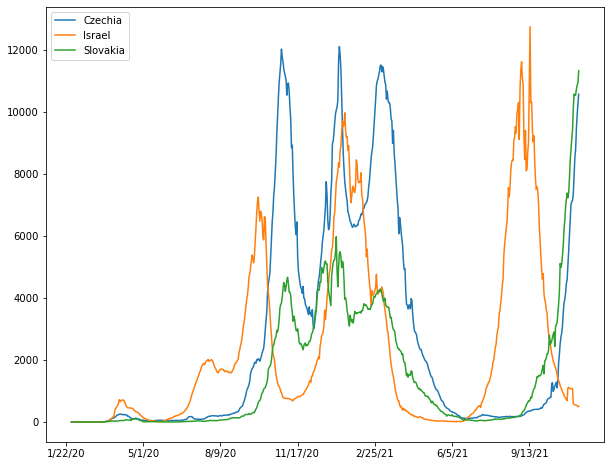

In [20]:
#countries = ['Czechia', 'Belgium', 'Italy', 'France', 'Israel', 'Slovakia']
countries = ['Czechia', 'Israel', 'Slovakia']
for country in countries:
    adjusted_increments[country].rolling(window=N).mean().plot(figsize=(10,8))

plt.legend()